# SMACNP Predictions: ERA5 Context → PeakWeather Station Locations

This notebook loads a trained SMACNP model (from **training_notebook_smacnp.ipynb**) and evaluates it at PeakWeather station locations using ERA5 as context — the same context source used during training, but with PW observations as ground truth instead of the MeteoSwiss grid.

**Data flow:** ERA5-Land grid (1769 cells, context) → SMACNP → predictions at all 174 valid PW station locations → compared against PW observations.

This is a **cross-dataset transfer evaluation**: the model was trained to downscale ERA5 to the MeteoSwiss grid, and here we test whether the learned mapping generalizes to arbitrary point locations using true GPS-precise station altitudes.

For each fold, we:
1. Load the trained model checkpoint
2. Identify the holdout ERA5 time period for that fold
3. For each holdout day, run inference at all 174 valid PW station locations
4. Match predictions to PW ground truth on the common date axis (a 1-day offset correction aligns ERA5 and PW timestamps)
5. Plot an observed-vs-predicted scatter for one representative day

After all folds, the holdout predictions are concatenated to produce a unified evaluation:
- Per-station error maps (MAE, RMSE, Bias)
- Uncertainty calibration (predicted σ vs actual error)
- Error correlations with altitude and mTPI
- Temporal error patterns (day-of-year analysis)
- CRPS for probabilistic calibration
- Q-Q plot (PIT-based) and reliability diagram


In [26]:
%pip install -qq -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [27]:
MODEL_NAME = 'test-2023-30e-5f-smacnp-mean-2000sub'
PW_FIRST_DATE = '2023-01-01'
PW_LAST_DATE  = '2024-12-31'
PW_VALIDITY_THRESHOLD = 0.99

# Number of target points per forward pass — reduce if GPU OOM, raise for speed
CHUNK_SIZE = 5000

In [28]:
from pathlib import Path

import params

params.configure_renku_cuda()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

import datasets as ds
import inference as inf
import metrics
import model_factory
import visualization as vis
from convCNP.training.training_elev import get_fold_holdout_indices, select_holdout_day

In [29]:
device = params.select_device()
print(f'Using device: {device}')

Using device: cuda


## Configuration

Specify the trained model directory to load.

In [30]:
# Path to trained model directory
MODEL_DIR = Path('./trained_models') / MODEL_NAME

# Default data paths (used as fallback for older checkpoints without saved paths)
DEFAULT_ERA5_MAX_TEMP_GLOB = './datasets/ERA5_Land/max_temperature/*.nc'
DEFAULT_ERA5_MEAN_TEMP_GLOB = './datasets/ERA5_Land/temperature/*.nc'
DEFAULT_ERA5_GEOPOTENTIAL_GLOB = './datasets/ERA5_Land/geopotential/*.nc'
DEFAULT_METEO_SWISS_MAX_TEMP_GLOB = './datasets/MeteoSwiss/TmaxD_v2.0_swiss.lv95/*.nc'
DEFAULT_METEO_SWISS_MEAN_TEMP_GLOB  = './datasets/MeteoSwiss/TabsD_v2.0_swiss.lv95/*.nc'
DEFAULT_HI_RES_TOPOGRAPHY_ZARR_PATH = './datasets/topo_subset.zarr'

In [31]:
# Build plot output directory and filename prefix
PLOT_DIR = MODEL_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

def plot_path(name: str) -> Path:
    return PLOT_DIR / f"{name}.png"

print(f"Plots will be saved to: {PLOT_DIR}")

Plots will be saved to: trained_models/test-2023-30e-5f-smacnp-mean-2000sub/plots


## Load Training Configuration

In [32]:
# Load params and metadata from training
params = params.Params.load_json(MODEL_DIR / 'params.json')
metadata = ds.load_metadata_json(MODEL_DIR / 'metadata.json')

TEMPERATURE_TYPE = getattr(params, 'TEMPERATURE_TYPE', 'max') 

# Override data paths from saved params (fall back to defaults for older checkpoints)
ERA5_GEOPOTENTIAL_GLOB = params.ERA5_GEOPOTENTIAL_GLOB or DEFAULT_ERA5_GEOPOTENTIAL_GLOB
HI_RES_TOPOGRAPHY_ZARR_PATH = params.HI_RES_TOPOGRAPHY_ZARR_PATH or DEFAULT_HI_RES_TOPOGRAPHY_ZARR_PATH

TEMPERATURE_TYPE = getattr(params, 'TEMPERATURE_TYPE', 'max')

if TEMPERATURE_TYPE == 'max':
    ERA5_TEMP_GLOB = params.ERA5_MAX_TEMP_GLOB or DEFAULT_ERA5_MAX_TEMP_GLOB
    ERA5_VAR_NAME  = 't2m_max'
else:
    ERA5_TEMP_GLOB = getattr(params, 'ERA5_MEAN_TEMP_GLOB', None) or DEFAULT_ERA5_MEAN_TEMP_GLOB
    ERA5_VAR_NAME  = 't2m'


print(f"Loaded configuration for run: {params.TRIAL_NAME}")
print(f"  Variable: {params.VARIABLE}")
print(f"  Data year start: {params.DATA_YEAR_START}")
print(f"  N folds: {params.N_FOLDS}")
print(f"  Model: {params.N_CHANNELS} channels, {params.N_BLOCKS} blocks")
print(f"  ERA5 max temp: {ERA5_TEMP_GLOB}")
print(f"  ERA5 geopotential: {ERA5_GEOPOTENTIAL_GLOB}")
print(f"  Topography: {HI_RES_TOPOGRAPHY_ZARR_PATH}")
print(f"Temperature type: {TEMPERATURE_TYPE}") 

Loaded configuration for run: test-2023-30e-5f-smacnp-mean-2000sub
  Variable: tmax
  Data year start: 2023
  N folds: 5
  Model: 128 channels, 6 blocks
  ERA5 max temp: datasets/ERA5_Land/temperature/*.nc
  ERA5 geopotential: datasets/ERA5_Land/geopotential/*.nc
  Topography: datasets/topo_subset.zarr
Temperature type: mean


## Load Data

In [33]:
# Load ERA5 input data with geopotential
era5_data, _, era5_grid_elevation, era5_times = ds.load_era5_data(
    ERA5_TEMP_GLOB,
    var_name=ERA5_VAR_NAME,
    year_start=params.DATA_YEAR_START,
    geopotential_glob=ERA5_GEOPOTENTIAL_GLOB,
    include_seasonal_embeddings=params.SEASONAL_FEATURES,
    device=device
)

print(f"ERA5 data shape: {era5_data.shape}")
print(f"Time coordinates: {len(era5_times)} dates from {era5_times[0]} to {era5_times[-1]}")

# Compute seasonal features from time coordinates if the model was trained with them
# SEASONAL_FEATURES=False should disable seasonal features everywhere.
# The model's use_seasonal_in_mlp flag (from SEASONAL_FEATURES_IN_MLP) independently
# controls whether the MLP actually uses these features.
if params.SEASONAL_FEATURES:
    seasonal_features = ds.compute_seasonal_features(era5_times, device=device)
    print(f"Seasonal features shape: {seasonal_features.shape}  # (n_times, 2) for [cos_doy, sin_doy]")
else:
    seasonal_features = None
    print("Seasonal features disabled (model was trained without them)")

# Load high-resolution topography (DEM and TPI)
hi_res_elevation, hi_res_tpi = ds.load_high_res_topography(HI_RES_TOPOGRAPHY_ZARR_PATH)

Loading ERA5 data from: datasets/ERA5_Land/temperature/*.nc


Dataset loaded with dimensions: FrozenMappingWarningOnValuesAccess({'time': 23376, 'latitude': 29, 'longitude': 61})
Original dataset time range: 1960-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
Filtered dataset time range from 2023: 2023-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
Filtered dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 365, 'latitude': 29, 'longitude': 61})
Calculating stats for t2m (Kelvin)...
tensor_Z torch tensor with shape (time, channel, lat, lon): torch.Size([365, 5, 29, 61]), dtype: torch.float32

Loading geopotential data from: datasets/ERA5_Land/geopotential/*.nc
Geopotential dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 1, 'latitude': 51, 'longitude': 81})
Geopotential lat range: [44.0000, 49.0000], shape: (51,)
Geopotential lon range: [4.0000, 12.0000], shape: (81,)
ERA5 data lat range: [45.4000, 48.2000], shape: (29,)
ERA5 data lon range: [5.0000, 11.0000], shape: (61,)
✓ ERA5 grid points are s

In [34]:
daily_tmax_pw, stations_meta, valid_stations = ds.load_peakweather_stations(
    first_date=PW_FIRST_DATE,
    last_date=PW_LAST_DATE,
    validity_threshold=PW_VALIDITY_THRESHOLD,
    aggregation_method='mean' if TEMPERATURE_TYPE == 'mean' else 'max',
)
daily_tmax_pw.index = daily_tmax_pw.index - pd.Timedelta(days=1)   # shift of 1 day to compensate the day difference between PW and ERA5 or Meteoswiss data
era5_dates_pd = pd.DatetimeIndex([str(t)[:10] for t in era5_times])

Loading PeakWeather stations (None) from 2023-01-01 to 2024-12-31 ...


  174 / 302 stations pass validity threshold (99%)
  Daily tmax shape: (730, 174)  (2023-01-01 → 2024-12-30)
  Altitude range: [203, 3571] m


In [35]:
# SMACNP takes point-format inputs — flatten ERA5 grid into N context points
x_context, y_context = ds.build_smacnp_context(era5_data)
print(f"x_context: {x_context.shape}   # (T, N_era5_cells, 6)")
print(f"y_context: {y_context.shape}   # (T, N_era5_cells, 1)")

x_context: torch.Size([365, 1769, 6])   # (T, N_era5_cells, 6)
y_context: torch.Size([365, 1769, 1])   # (T, N_era5_cells, 1)


In [36]:
x_target_static = ds.prepare_peakweather_targets(
    stations_meta=stations_meta,
    hi_res_tpi=hi_res_tpi,
    metadata=metadata,
    device=device,
)
n_pw = x_target_static.shape[0]

def make_x_target_day(day_idx: int) -> torch.Tensor:
    if seasonal_features is not None:
        seas = seasonal_features[day_idx].unsqueeze(0).expand(n_pw, -1)
        return torch.cat([x_target_static, seas], dim=-1)
    return x_target_static

print(f"x_target_static: {x_target_static.shape}   # (n_stations, 4)")

x_target_static: torch.Size([174, 4])   # (n_stations, 4)


## Generate Predictions for Each Fold

For each fold, we load the trained model, plot a single representative holdout day, and accumulate predictions over the full holdout period for combined analysis.

Fold 1/5
Built SMACNP with 308,995 trainable parameters
  Loaded epoch 27 | holdout 2023-01-01 → 2023-03-14


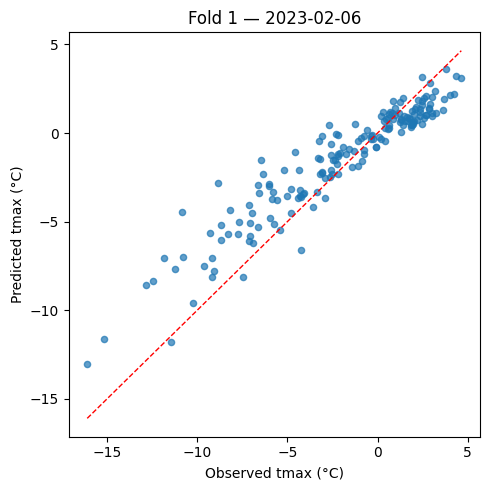

  Fold 1 done: 73 days
Fold 2/5
Built SMACNP with 308,995 trainable parameters
  Loaded epoch 28 | holdout 2023-03-15 → 2023-05-26


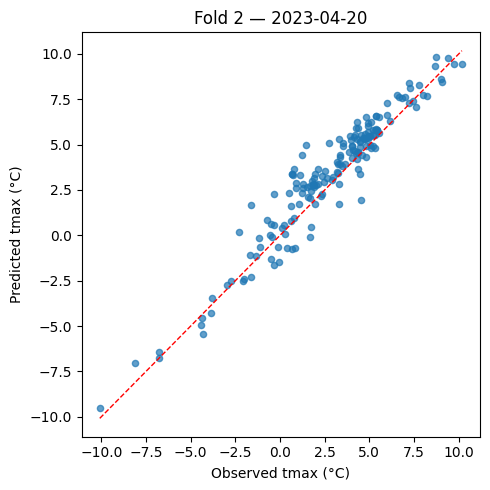

  Fold 2 done: 73 days
Fold 3/5
Built SMACNP with 308,995 trainable parameters
  Loaded epoch 23 | holdout 2023-05-27 → 2023-08-07


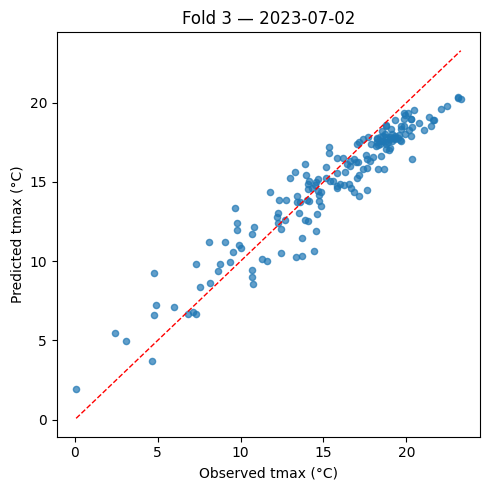

  Fold 3 done: 73 days
Fold 4/5
Built SMACNP with 308,995 trainable parameters
  Loaded epoch 25 | holdout 2023-08-08 → 2023-10-19


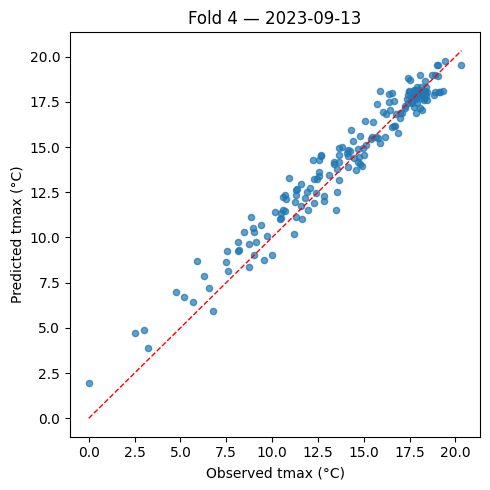

  Fold 4 done: 73 days
Fold 5/5
Built SMACNP with 308,995 trainable parameters
  Loaded epoch 18 | holdout 2023-10-20 → 2023-12-31


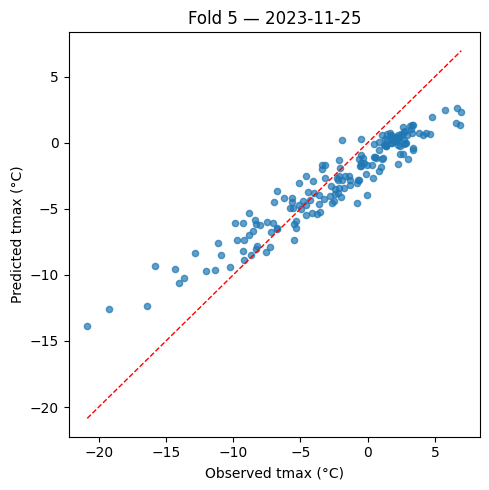

  Fold 5 done: 73 days

Combined: 365 days × 174 stations


In [37]:
n_samples = era5_data.shape[0]

combined_preds, combined_sigmas, combined_truths, combined_dates = [], [], [], []

for fold in range(params.N_FOLDS):
    print(f"{'='*60}\nFold {fold+1}/{params.N_FOLDS}\n{'='*60}")

    checkpoint_path = MODEL_DIR / f'model_fold_{fold}'
    if not checkpoint_path.exists():
        print(f"  Checkpoint not found: {checkpoint_path}")
        continue

    model, epoch = model_factory.load_model_checkpoint(
        checkpoint_path, params, device, input_dim=x_context.shape[-1]
    )
    holdout_start, holdout_end = get_fold_holdout_indices(fold, params.N_FOLDS, n_samples)
    print(f"  Loaded epoch {epoch} | holdout {era5_dates_pd[holdout_start].date()} "
          f"→ {era5_dates_pd[holdout_end-1].date()}")

    fold_preds, fold_sigmas, fold_truths, fold_dates = [], [], [], []

    with torch.no_grad():
        for day_idx in range(holdout_start, holdout_end):
            date = era5_dates_pd[day_idx]
            if date not in daily_tmax_pw.index:
                continue
            true_vals = daily_tmax_pw.loc[date, valid_stations].values.astype(np.float32)
            if np.all(np.isnan(true_vals)):
                continue

            x_target_day = make_x_target_day(day_idx)
            preds_day, sigmas_day = inf.predict_single_day_smacnp(
                model, x_context, y_context, x_target_day, day_idx, device, n_pw
            )
            preds_degC = metadata.denormalize(preds_day.cpu().numpy()) - ds.KELVIN_OFFSET

            fold_preds.append(preds_degC)
            fold_sigmas.append(sigmas_day.cpu().numpy())
            fold_truths.append(true_vals)
            fold_dates.append(date)

    if not fold_preds:
        print(f"  No PeakWeather coverage — skipping")
        continue

    # Single-day scatter plot: predicted vs observed across stations
    day_pred  = fold_preds[len(fold_preds) // 2]
    day_truth = fold_truths[len(fold_truths) // 2]
    day_date  = fold_dates[len(fold_dates) // 2]
    valid     = ~np.isnan(day_truth)
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(day_truth[valid], day_pred[valid], alpha=0.7, s=20)
    lims = [min(day_truth[valid].min(), day_pred[valid].min()),
            max(day_truth[valid].max(), day_pred[valid].max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel('Observed tmax (°C)')
    ax.set_ylabel('Predicted tmax (°C)')
    ax.set_title(f'Fold {fold+1} — {day_date.date()}')
    plt.tight_layout()
    plt.savefig(plot_path(f'fold{fold}_scatter'))
    plt.show()

    combined_preds.append(np.stack(fold_preds))
    combined_sigmas.append(np.stack(fold_sigmas))
    combined_truths.append(np.stack(fold_truths))
    combined_dates.extend(fold_dates)
    print(f"  Fold {fold+1} done: {len(fold_preds)} days")

all_preds   = np.concatenate(combined_preds,  axis=0)   # (n_days, n_stations)
all_sigmas  = np.concatenate(combined_sigmas, axis=0)
all_truths  = np.concatenate(combined_truths, axis=0)
all_errors  = all_preds - all_truths
sigma_degC  = all_sigmas * metadata.data_std             # denormalize for calibration
total_days  = all_preds.shape[0]
print(f"\nCombined: {total_days} days × {all_preds.shape[1]} stations")


## Combined Holdout Analysis (All Folds)

The following plots use the concatenated holdout predictions from all folds, covering the entire year.

Overall MAE:   1.292 °C
Overall RMSE:  1.654 °C
Overall Bias:  -0.115 °C
Overall CRPS:  0.936 °C


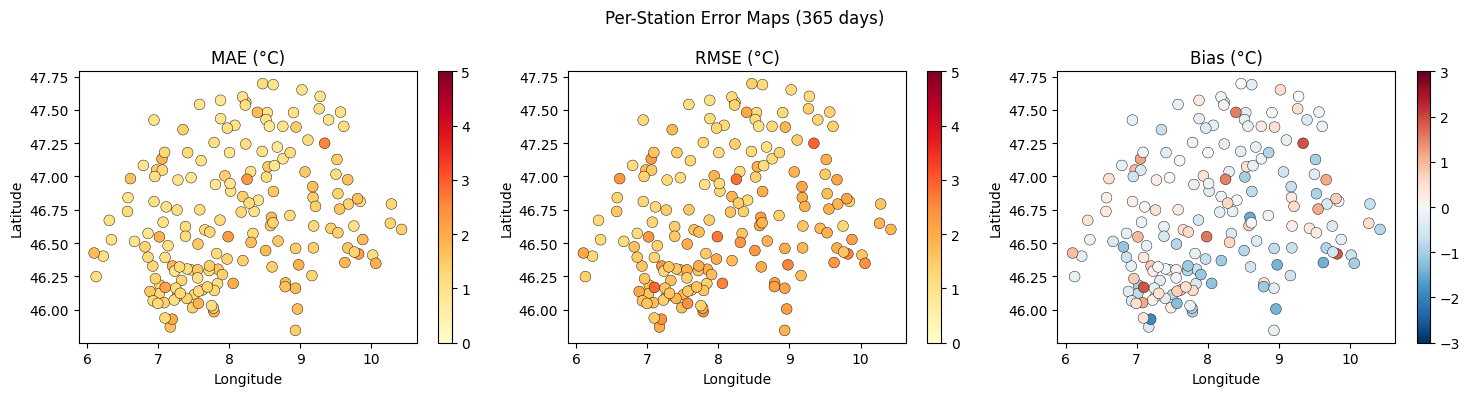

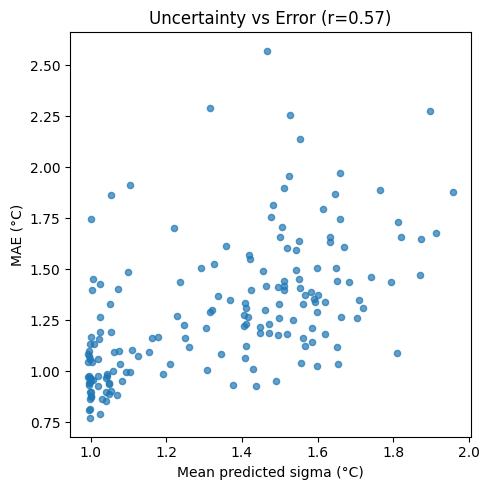

Per-station uncertainty-error correlation: 0.566


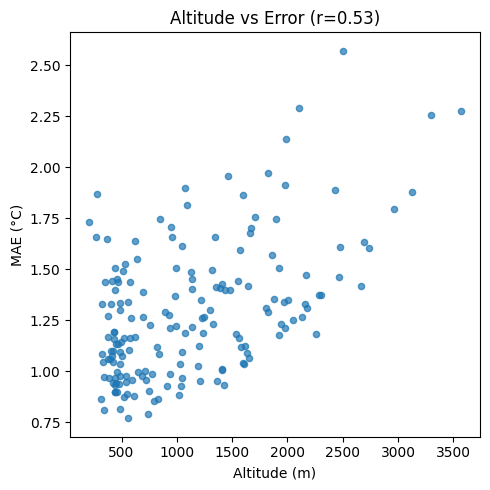

Altitude-error correlation: 0.528


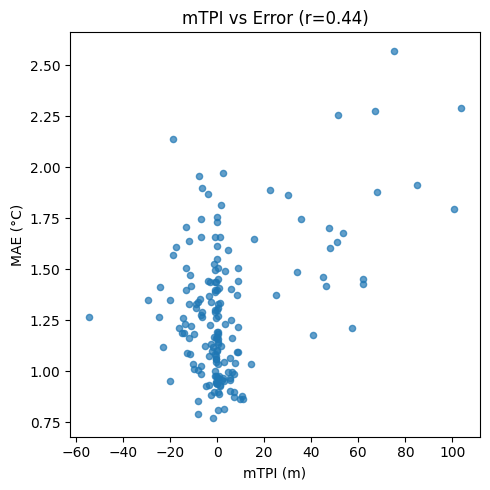

mTPI-error correlation: 0.435
  Saved plot: trained_models/test-2023-30e-5f-smacnp-mean-2000sub/plots/doy_vs_error.png


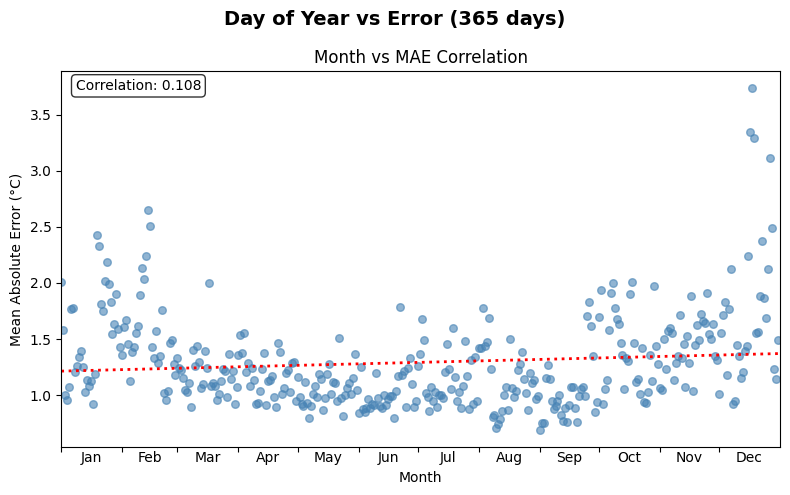

Day of year-error correlation: 0.108


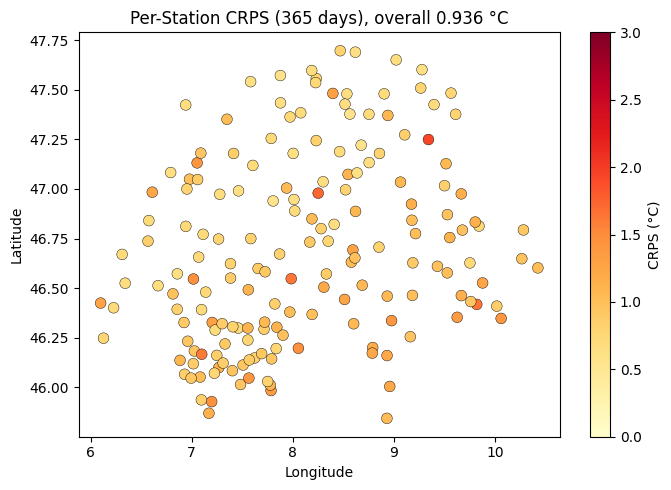

In [38]:
station_lats = stations_meta['latitude'].values
station_lons = stations_meta['longitude'].values
station_alts = stations_meta['station_height'].values
station_tpi  = (x_target_static[:, 3].cpu().numpy() * 400.0) - 200.0  # denorm mTPI

mae_per_station  = np.nanmean(np.abs(all_errors), axis=0)
rmse_per_station = np.sqrt(np.nanmean(all_errors**2, axis=0))
bias_per_station = np.nanmean(all_errors, axis=0)

import properscoring as ps
crps_per_station = np.nanmean(
    ps.crps_gaussian(all_truths, mu=all_preds, sig=sigma_degC), axis=0
)
sigma_per_station = np.nanmean(sigma_degC, axis=0)

print(f"Overall MAE:   {np.nanmean(mae_per_station):.3f} °C")
print(f"Overall RMSE:  {np.nanmean(rmse_per_station):.3f} °C")
print(f"Overall Bias:  {np.nanmean(bias_per_station):.3f} °C")
print(f"Overall CRPS:  {np.nanmean(crps_per_station):.3f} °C")

# 1. Station error map
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, vals, title, cmap, vmin, vmax in zip(
    axes,
    [mae_per_station, rmse_per_station, bias_per_station],
    ['MAE (°C)', 'RMSE (°C)', 'Bias (°C)'],
    ['YlOrRd', 'YlOrRd', 'RdBu_r'],
    [0, 0, -3], [5, 5, 3],
):
    sc = ax.scatter(station_lons, station_lats, c=vals, cmap=cmap,
                    vmin=vmin, vmax=vmax, s=60, edgecolors='k', linewidths=0.3)
    plt.colorbar(sc, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
fig.suptitle(f'Per-Station Error Maps ({total_days} days)')
plt.tight_layout()
plt.savefig(plot_path('error_maps'))
plt.show()

# 2. Uncertainty vs error (per station)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(sigma_per_station, mae_per_station, alpha=0.7, s=20)
ax.set_xlabel('Mean predicted sigma (°C)')
ax.set_ylabel('MAE (°C)')
corr = np.corrcoef(sigma_per_station, mae_per_station)[0, 1]
ax.set_title(f'Uncertainty vs Error (r={corr:.2f})')
plt.tight_layout()
plt.savefig(plot_path('uncertainty_vs_error'))
plt.show()
print(f"Per-station uncertainty-error correlation: {corr:.3f}")

# 3. Altitude vs error
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(station_alts, mae_per_station, alpha=0.7, s=20)
ax.set_xlabel('Altitude (m)')
ax.set_ylabel('MAE (°C)')
corr_alt = np.corrcoef(station_alts, mae_per_station)[0, 1]
ax.set_title(f'Altitude vs Error (r={corr_alt:.2f})')
plt.tight_layout()
plt.savefig(plot_path('altitude_vs_error'))
plt.show()
print(f"Altitude-error correlation: {corr_alt:.3f}")

# 4. mTPI vs error
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(station_tpi, mae_per_station, alpha=0.7, s=20)
ax.set_xlabel('mTPI (m)')
ax.set_ylabel('MAE (°C)')
corr_tpi = np.corrcoef(station_tpi, mae_per_station)[0, 1]
ax.set_title(f'mTPI vs Error (r={corr_tpi:.2f})')
plt.tight_layout()
plt.savefig(plot_path('mtpi_vs_error'))
plt.show()
print(f"mTPI-error correlation: {corr_tpi:.3f}")

# 5. Day of year vs error (reuses existing visualization function)
all_holdout_dates = np.array(combined_dates, dtype='datetime64')
fig_doy, doy_corr = vis.plot_temporal_error_analysis(
    all_errors=all_errors,
    holdout_dates=all_holdout_dates,
    title=f'Day of Year vs Error ({total_days} days)',
    save_path=plot_path('doy_vs_error'),
)
plt.show()
print(f"Day of year-error correlation: {doy_corr:.3f}")

# 6. CRPS station map
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(station_lons, station_lats, c=crps_per_station,
                cmap='YlOrRd', vmin=0, vmax=3, s=60,
                edgecolors='k', linewidths=0.3)
plt.colorbar(sc, ax=ax, label='CRPS (°C)')
ax.set_title(f'Per-Station CRPS ({total_days} days), '
             f'overall {np.nanmean(crps_per_station):.3f} °C')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(plot_path('crps_map'))
plt.show()


  Saved plot: trained_models/test-2023-30e-5f-smacnp-mean-2000sub/plots/qq_calibration.png


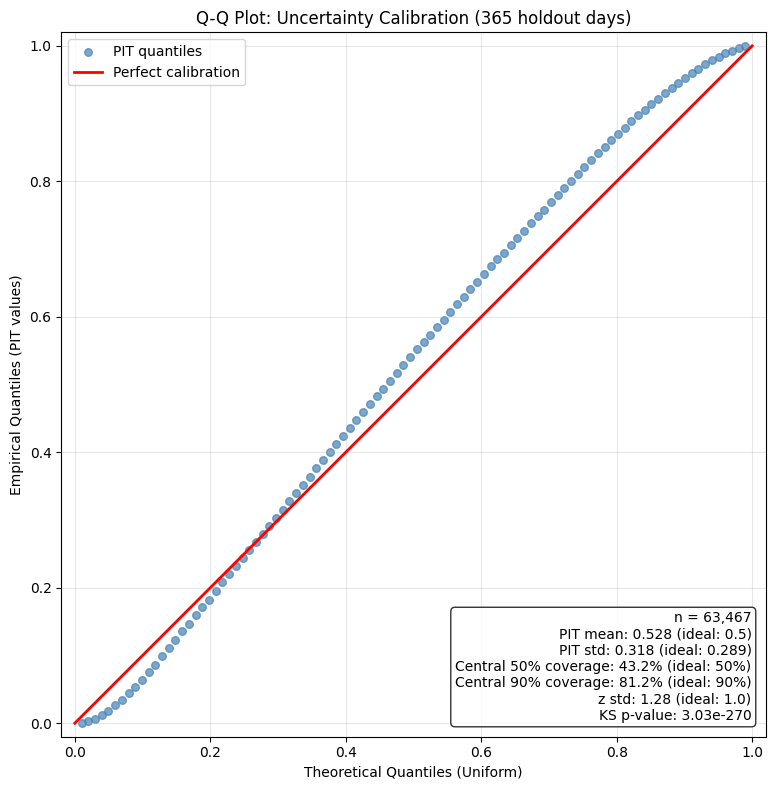


Calibration statistics:
  PIT mean: 0.528 (ideal: 0.5)
  PIT std:  0.318 (ideal: 0.289)
  z std:    1.28 (ideal: 1.0)
  50% coverage: 43.2% (ideal: 50%)
  90% coverage: 81.2% (ideal: 90%)
  KS test p-value: 3.03e-270


In [39]:
from importlib import reload
vis = reload(vis)
# 8. Q-Q plot for uncertainty calibration
# Assesses whether the model's predicted uncertainty (sigma) is correctly calibrated.
# For a well-calibrated Gaussian model, PIT values (CDF of truth under predicted distribution)
# should follow Uniform(0, 1).
fig_qq, calibration_stats = vis.plot_qq_calibration(
    all_truths=all_truths,
    all_preds=all_preds,
    all_sigmas=sigma_degC,
    title=f"Q-Q Plot: Uncertainty Calibration ({total_days} holdout days)",
    save_path=plot_path("qq_calibration"),
)
plt.show()

print("\nCalibration statistics:")
print(f"  PIT mean: {calibration_stats['pit_mean']:.3f} (ideal: 0.5)")
print(f"  PIT std:  {calibration_stats['pit_std']:.3f} (ideal: 0.289)")
print(f"  z std:    {calibration_stats['z_std']:.2f} (ideal: 1.0)")
print(f"  50% coverage: {calibration_stats['coverage_50']:.1%} (ideal: 50%)")
print(f"  90% coverage: {calibration_stats['coverage_90']:.1%} (ideal: 90%)")
print(f"  KS test p-value: {calibration_stats['ks_p']:.3g}")

  Saved plot: trained_models/test-2023-30e-5f-smacnp-mean-2000sub/plots/reliability_diagram.png


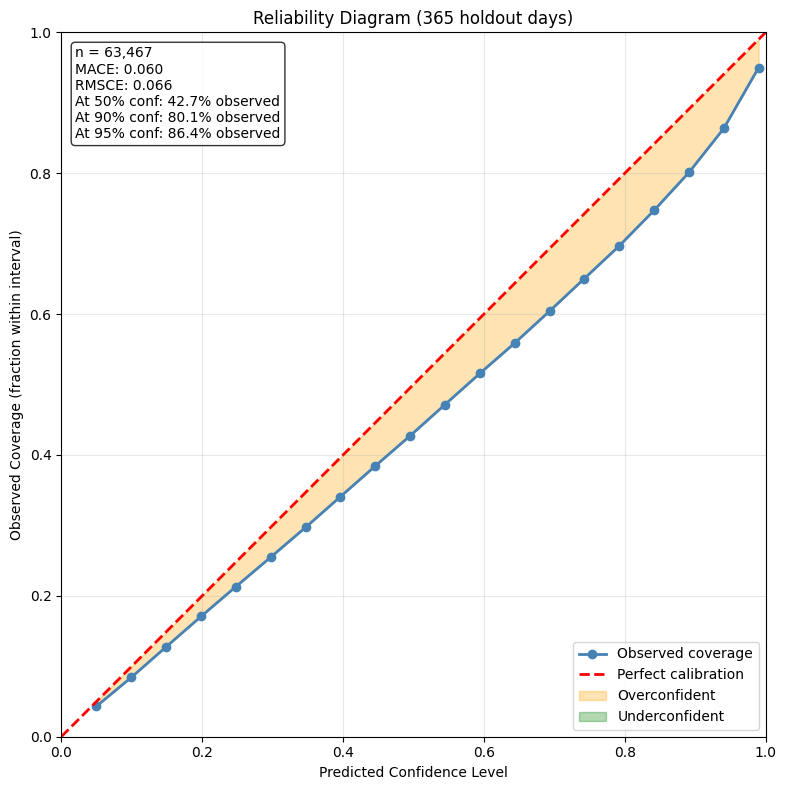


Reliability statistics:
  Mean Absolute Calibration Error (MACE): 0.060
  At 50% confidence: 42.7% observed (ideal: 50%)
  At 90% confidence: 80.1% observed (ideal: 90%)
  At 95% confidence: 86.4% observed (ideal: 95%)


In [40]:
# 9. Reliability diagram for uncertainty calibration
# Shows predicted confidence level vs observed coverage.
# If well-calibrated, the curve should follow the diagonal.
fig_reliability, reliability_stats = vis.plot_reliability_diagram(
    all_truths=all_truths,
    all_preds=all_preds,
    all_sigmas=sigma_degC,
    title=f"Reliability Diagram ({total_days} holdout days)",
    save_path=plot_path("reliability_diagram"),
)
plt.show()

print("\nReliability statistics:")
print(f"  Mean Absolute Calibration Error (MACE): {reliability_stats['mace']:.3f}")
print(f"  At 50% confidence: {reliability_stats['coverage_at_50']:.1%} observed (ideal: 50%)")
print(f"  At 90% confidence: {reliability_stats['coverage_at_90']:.1%} observed (ideal: 90%)")
print(f"  At 95% confidence: {reliability_stats['coverage_at_95']:.1%} observed (ideal: 95%)")

In [41]:
import json

metrics_path = MODEL_DIR / 'metrics.json'

metrics_dict = {
    "config": {
        "model_name": MODEL_NAME,
        "inference_dataset": "peakweather",
        "n_stations": int(n_pw),
        "n_folds": params.N_FOLDS,
        "holdout_days": int(total_days),
        "pw_first_date": PW_FIRST_DATE,
        "pw_last_date": PW_LAST_DATE,
        "pw_validity_threshold": PW_VALIDITY_THRESHOLD,
    },
    "overall": {
        "mae":  float(np.nanmean(mae_per_station)),
        "rmse": float(np.nanmean(rmse_per_station)),
        "bias": float(np.nanmean(bias_per_station)),
        "crps": float(np.nanmean(crps_per_station)),
    },
    "correlations": {
        "uncertainty_error": float(corr),
        "altitude_error":    float(corr_alt),
        "mtpi_error":        float(corr_tpi),
        "doy_error":         float(doy_corr),
    },
    "calibration": {
        "pit_mean":    float(calibration_stats["pit_mean"]),
        "pit_std":     float(calibration_stats["pit_std"]),
        "z_std":       float(calibration_stats["z_std"]),
        "coverage_50": float(calibration_stats["coverage_50"]),
        "coverage_90": float(calibration_stats["coverage_90"]),
        "ks_p_value":  float(calibration_stats["ks_p"]),
    },
    "reliability": {
        "mace":            float(reliability_stats["mace"]),
        "coverage_at_50":  float(reliability_stats["coverage_at_50"]),
        "coverage_at_90":  float(reliability_stats["coverage_at_90"]),
        "coverage_at_95":  float(reliability_stats["coverage_at_95"]),
    },
}
metrics_path.write_text(json.dumps(metrics_dict, indent=2))
print(f"Metrics saved to {metrics_path}")

Metrics saved to trained_models/test-2023-30e-5f-smacnp-mean-2000sub/metrics.json


In [42]:
# Load one fold's model without running the full prediction loop
grid_shape = (240, 370)

fold = 4   # any fold works for attention visualization
checkpoint_path = MODEL_DIR / f'model_fold_{fold}'
model, epoch = model_factory.load_model_checkpoint(
    checkpoint_path, params, device, input_dim=x_context.shape[-1]
)
print(f"Loaded model from fold {fold}, epoch {epoch}")

Built SMACNP with 308,995 trainable parameters
Loaded model from fold 4, epoch 18


Zurich: target_point_idx=128, matched (47.3779°N, 8.5657°E), 1.87 km away


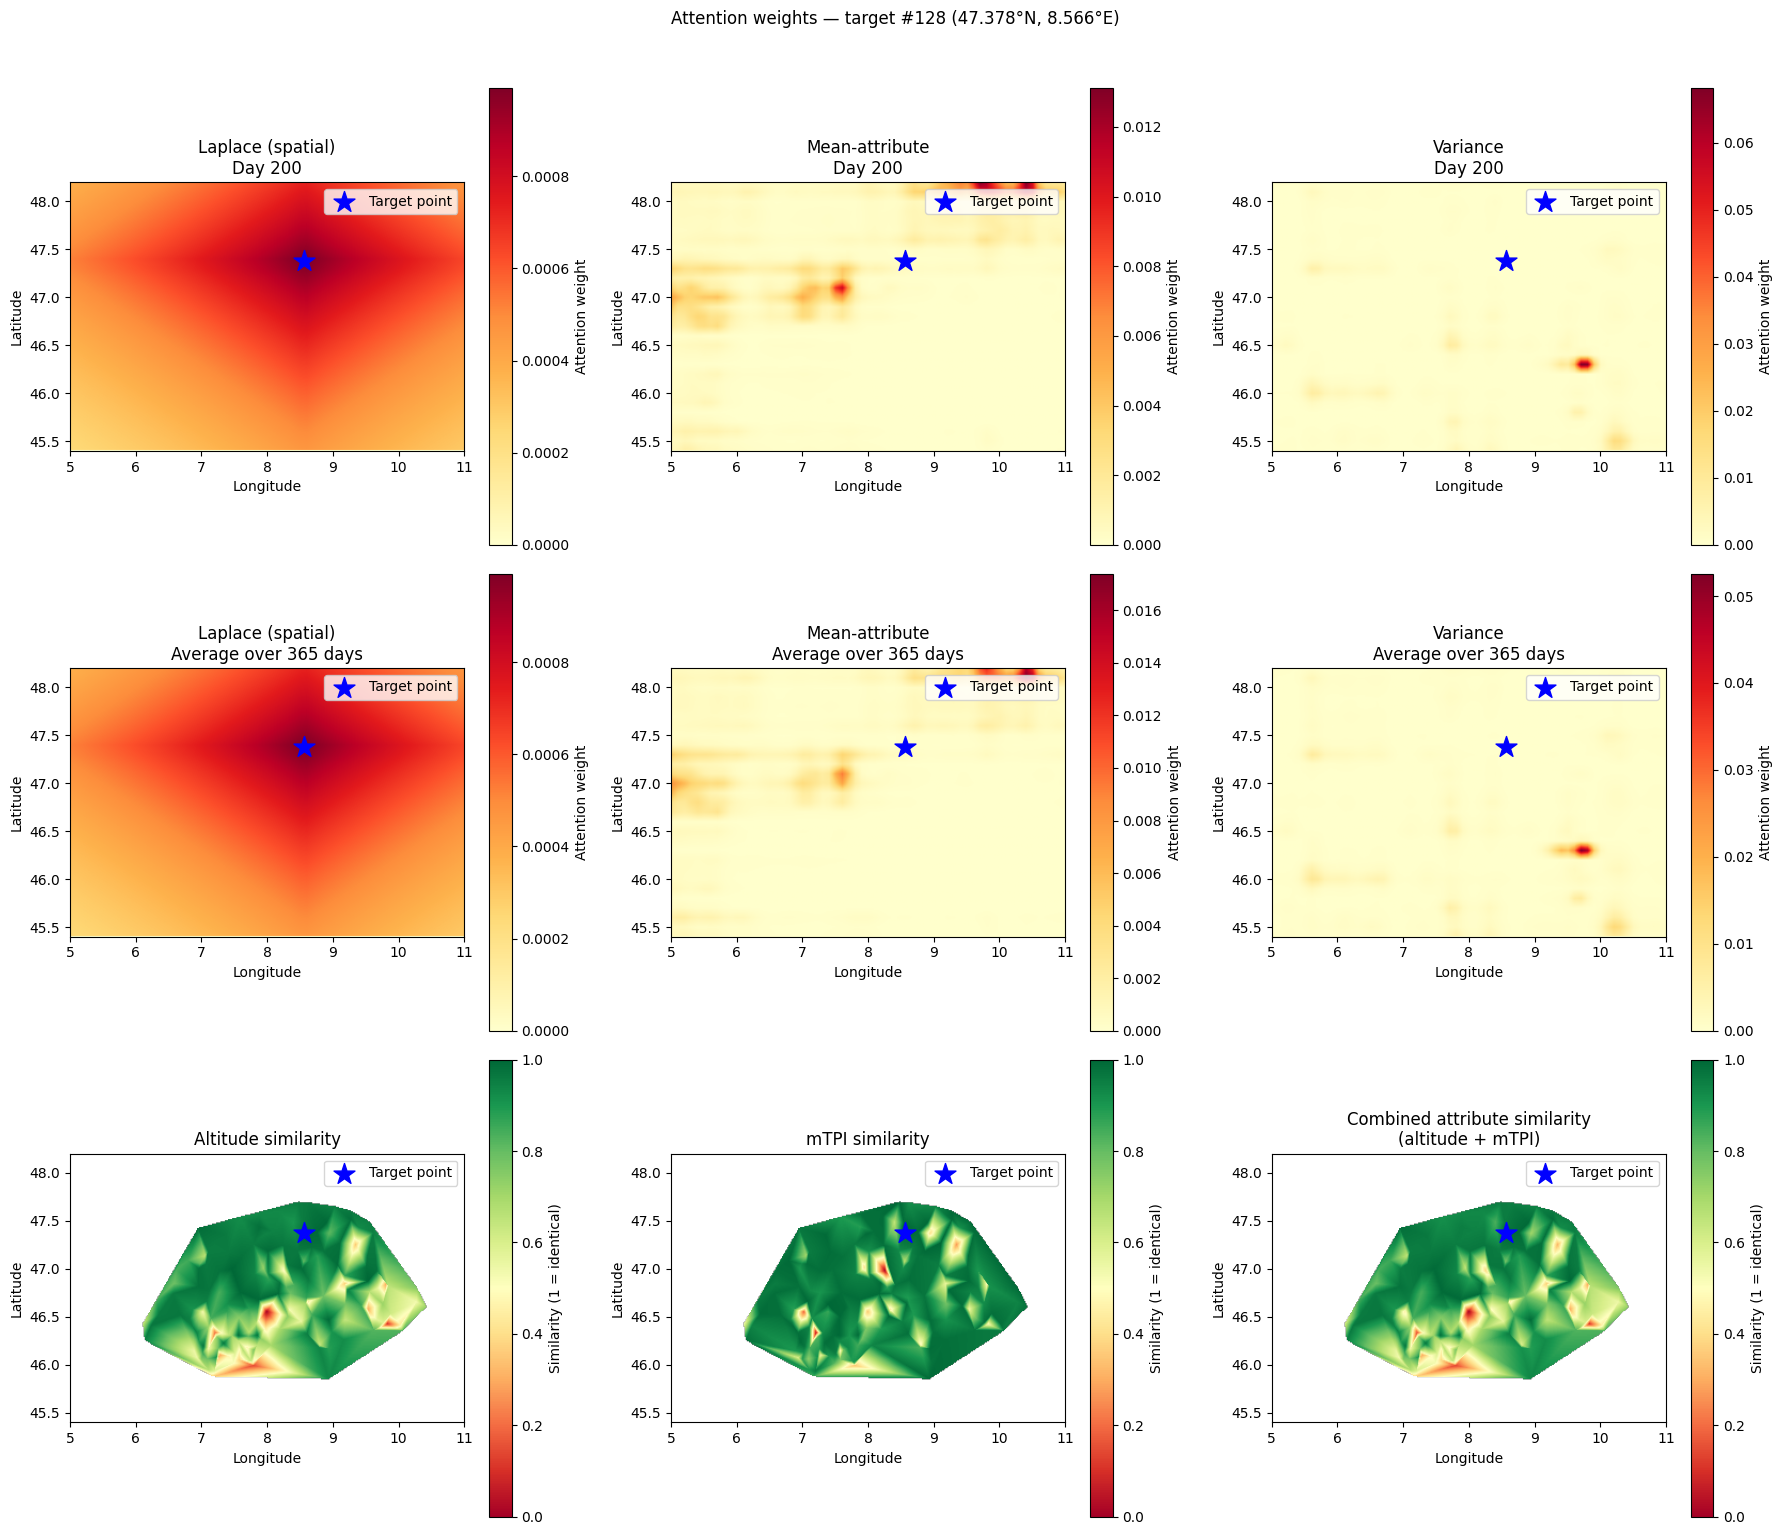

In [43]:
from importlib import reload
import visualization as vis
vis = reload(vis)
from visualization import get_lat_lon_arrays, find_target_point, plot_attention_maps

# Some predefined reference points for which attention can be visualized:
LOCATIONS = {
    'Zurich':   (47.376, 8.541),
    'Geneva':   (46.204, 6.143),
    'Neuchatel':(46.990, 6.929), 
    'Bern':     (46.948, 7.447),
    'Zermatt':  (46.020, 7.749),
    'Davos':    (46.803, 9.837),
    'Other':    (45.930, 7.860),
}

context_lats, context_lons, target_lats, target_lons = vis.get_lat_lon_arrays(
    x_context, x_target_static, metadata
)

name = 'Zurich'  # Select the point for which the attention map should be displayed
lat, lon = LOCATIONS[name]
idx, matched_lat, matched_lon, dist_km = find_target_point(lat, lon, target_lats, target_lons)
print(f"{name}: target_point_idx={idx}, matched ({matched_lat:.4f}°N, {matched_lon:.4f}°E), {dist_km:.2f} km away")

SHOW_AVERAGE = True
SHOW_SIMILARITY = True

viz_lats_1d = np.linspace(metadata.lat_min, metadata.lat_max, 240)
viz_lons_1d = np.linspace(metadata.lon_min, metadata.lon_max, 370)

fig = vis.plot_attention_maps(
    model=model, x_context=x_context, y_context=y_context,
    x_target_static=x_target_static, day_idx=200, target_point_idx=idx,
    grid_shape=grid_shape, metadata=metadata, device=device,
    y_target_flat=None,
    show_average=SHOW_AVERAGE,
    show_similarity=SHOW_SIMILARITY,
    viz_grid_lats_1d=viz_lats_1d,
    viz_grid_lons_1d=viz_lons_1d,
)

## Summary

This notebook demonstrates how to:
1. Load trained SMACNP models (ERA5 → MeteoSwiss grid) using saved configuration (one per fold)
2. Reconstruct the holdout ERA5 time periods used during cross-validation
3. Build ERA5 context for each holdout day (identical to the training setup)
4. **Per-fold:** Generate predictions at all 174 valid PeakWeather station locations
   and plot a scatter of observed vs predicted temperatures for a representative day
5. **Combined across all folds:** Since holdout periods are non-overlapping,
   predictions from all folds are concatenated to produce a unified evaluation:
   - Per-station error maps (MAE, RMSE, Bias)
   - Uncertainty calibration (predicted σ vs actual MAE per station)
   - Error correlations with altitude and mTPI
   - Temporal error patterns (day-of-year analysis)
   - CRPS (Continuous Ranked Probability Score) for probabilistic calibration
   - Q-Q plot using Probability Integral Transform (PIT)
   - Reliability diagram for confidence calibration

### Cross-dataset interpretation
This notebook evaluates an ERA5-trained model at point locations using true GPS-precise station altitudes (from PeakWeather metadata), rather than the smoothed ERA5 orography seen during training. Higher errors at alpine stations may reflect the elevation mismatch between ERA5 grid-cell averages and the actual terrain at the station.

### Interpretation of correlation plots:
- **Uncertainty vs Error:** High correlation indicates good calibration — the model "knows where it doesn't know"
- **Altitude vs Error:** Positive correlation suggests the model struggles more at high elevations (likely amplified by ERA5 orography smoothing)
- **mTPI vs Error:** Positive values = ridges, negative = valleys. Correlation reveals terrain-dependent biases
- **Day of Year vs Error:** Reveals seasonal performance variations across the holdout period

### Interpretation of calibration plots:

**Q-Q Plot (PIT-based):**
- Computes PIT = CDF(truth | μ, σ) for each prediction
- If well-calibrated, PIT values should be Uniform(0,1)
- Points on diagonal = well-calibrated
- S-curve below diagonal = overconfident (intervals too narrow)
- S-curve above diagonal = underconfident (intervals too wide)

**Reliability Diagram:**
- X-axis: Predicted confidence level (e.g., 50%, 90%, 95%)
- Y-axis: Observed frequency (fraction of truths actually in that interval)
- Diagonal = perfect calibration
- Curve below diagonal (orange region) = overconfident
- Curve above diagonal (green region) = underconfident
- MACE (Mean Absolute Calibration Error) summarises miscalibration
